In [1]:
from joblib import Parallel, delayed
from tqdm.notebook import tqdm

import sys
import pickle
import numpy as np
import pandas as pd
import networkx as nx
import scipy
from itertools import combinations

In [2]:
for i in range(50):
    np.random.seed(i)
    
    G = grn().add_structure(
    n=256,
    k=1,
    alpha=1e-99,
    beta=0.99,       # 1 - 1/r
    gamma=0.01,      # 1/r
    kappa=10,        # --w
    delta_in=100,
    delta_out=100,
    )
    G.simulate_rna(
    s=1e-4,
    dt=1e-2,
    tmax=20000,
    burnin=5000,
    tol=1e-3,
    save=True,
    )
    B = G.beta 
    x = G.rna.flatten()
    l = G.l.flatten()
    a = G.alpha.flatten()
    
    # jacobian
    sig = scipy.special.expit(a + B.T@x.reshape(-1,1))
    #sig = (l*x)
    A = B.T * (sig * (1 - sig)) - np.diag(l)
    evals, evecs = np.linalg.eig(A)
       
    # result
    stable = all(evals.real < 0)
    print(i, 'has converged -', G.converged, 'and is stable -', stable)
    
    

NameError: name 'grn' is not defined

In [3]:
sys.path.insert(0, "src")

from grn import grn

np.random.seed(5)


In [4]:
#manually adjust GRN hyperparameters in an attempt to build GRN with more non-additive effects
G = grn().add_structure(
    n=256,
    k=1,
    alpha=1e-99,
    beta=0.99,       # 1 - 1/r
    gamma=0.01,      # 1/r
    kappa=10,        # --w
    delta_in=100,
    delta_out=100,
)

AttributeError: module 'networkx.convert_matrix' has no attribute 'to_numpy_matrix'

In [4]:
G.simulate_rna(
    s=1e-4,
    dt=1e-2,
    tmax=20000,
    burnin=5000,
    tol=1e-3,
    save=True,
)


array([[4.84649231e-10, 4.18872025e-01, 3.77322668e-03, 1.69880546e-10,
        1.06239300e+00, 3.58549281e-07, 5.00508449e-07, 1.01727610e+00,
        9.22185642e-05, 1.12122699e+00, 2.52883912e-02, 1.08584806e+00,
        1.25280245e-09, 1.20867685e+00, 1.53776463e+00, 1.08056495e-08,
        1.55010171e-04, 1.83459186e-06, 1.09137161e+00, 1.06043472e-09,
        1.08336101e+00, 8.00775265e-03, 1.21524535e+00, 2.25520557e-09,
        9.16532224e-03, 1.34900708e+00, 1.06786693e+00, 8.67781628e-01,
        8.78636767e-02, 1.01295853e+00, 8.87810232e-10, 1.04249830e+00,
        1.02088890e+00, 1.16010403e+00, 3.11985535e-03, 9.27389566e-01,
        1.93303618e-09, 9.72905997e-01, 1.06724803e+00, 1.32670786e-08,
        1.97531781e-03, 1.81200185e-01, 3.82578343e-04, 1.23273126e-06,
        1.06109423e+00, 1.41638243e+00, 1.19667148e+00, 9.15270357e-02,
        1.13071151e+00, 1.03317256e+00, 3.75856888e-07, 1.01290271e+00,
        1.08133226e+00, 1.20993819e+00, 1.05294511e+00, 1.630200

In [45]:
np.save('../256g_smallV2_rna', G.rna)

In [5]:
wt_expression = np.asarray(G.rna).flatten()

wt_df = pd.DataFrame(
    [wt_expression],
    index=["WT"],
    columns=[f"gene_{i}" for i in range(G.n)],
)

wt_df.to_csv("wt_expression.csv")

print("Converged:", G.converged)
print("Expression shape:", wt_expression.shape)
display(wt_df)

Converged: True
Expression shape: (256,)


,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,...,gene_246,gene_247,gene_248,gene_249,gene_250,gene_251,gene_252,gene_253,gene_254,gene_255
WT,4.846492e-10,0.418872,0.003773,1.698805e-10,1.062393,3.585493e-07,5.005084e-07,1.017276,0.000092,1.121227,...,0.001908,0.095047,0.00083,0.09104,0.1389,0.861876,0.868824,0.060821,0.122791,0.453823


In [6]:
B = G.beta 
x = G.rna.flatten()
l = G.l.flatten()
a = G.alpha.flatten()
    
# jacobian
sig = scipy.special.expit(a + B.T@x.reshape(-1,1))
#sig = (l*x)
A = B.T * (sig * (1 - sig)) - np.diag(l)
evals, evecs = np.linalg.eig(A)
       
# result
stable = all(evals.real < 0)
print(stable)

True


In [9]:
ko_expression = np.zeros((G.n, G.n))
ko_logfc = np.zeros((G.n, G.n))
ko_convergence = {}

for gene in tqdm(range(G.n), desc="Simulating single-gene KOs"):
    
    result = G.ko_nodes(
        genes=[gene],
        stats=("new_rna", 'logfc', 'convergence'),
        s=1e-4,
        dt=1e-2,
        tmax=20000,
        burnin=5000,
        tol=1e-3,
    )
    
    ko_expression[gene, :] = result["new_rna"].flatten()
    ko_logfc[gene, :] = result["logfc"].flatten()
    ko_convergence[gene] = result['convergence']

# Rows = perturbations
# Columns = measured genes
ko_df = pd.DataFrame(
    ko_expression,
    index=[f"KO_{i}" for i in range(G.n)],
    columns=[f"gene_{i}" for i in range(G.n)],
)

fc_ko_df = pd.DataFrame(
    ko_logfc,
    index=[f"KO_{i}" for i in range(G.n)],
    columns=[f"gene_{i}" for i in range(G.n)],
)



# Save KO expression only
ko_df.to_csv("single_KO_expression.csv")

# Also save one convenient combined WT + KO matrix
expression_df = pd.concat([wt_df, ko_df])

expression_df.to_csv("WT_and_single_KO_expression.csv")

print("KO matrix shape:", ko_df.shape)
print("Combined matrix shape:", expression_df.shape)

display(expression_df.head())

Simulating single-gene KOs:   0%|          | 0/256 [00:00<?, ?it/s]

KO matrix shape: (256, 256)
Combined matrix shape: (257, 256)


,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,...,gene_246,gene_247,gene_248,gene_249,gene_250,gene_251,gene_252,gene_253,gene_254,gene_255
WT,4.846492e-10,0.418872,0.003773,1.698805e-10,1.062393,3.585493e-07,5.005084e-07,1.017276,0.000092,1.121227,...,0.001908,0.095047,0.000830,0.091040,0.138900,0.861876,0.868824,0.060821,0.122791,0.453823
KO_0,5.691505e-10,0.419013,0.003773,3.416789e-10,1.062374,3.727746e-07,4.941724e-07,1.017298,0.000092,1.121226,...,0.001908,0.095019,0.000830,0.091037,0.138881,0.861859,0.868800,0.060826,0.122781,0.453791
KO_1,1.220889e-09,1.100530,0.001697,1.303521e-10,1.062154,8.907529e-07,1.020529e-08,1.017290,0.000670,1.121761,...,0.001932,0.114160,0.002033,0.089160,0.134574,0.861725,0.681974,0.095824,0.122420,0.453823
KO_2,5.853058e-10,0.423884,0.003900,3.609902e-10,1.062366,3.702087e-07,5.219970e-07,1.017288,0.000091,1.121244,...,0.001910,0.095680,0.000814,0.091025,0.138958,0.861886,0.867849,0.060491,0.123396,0.453844
KO_3,4.155808e-10,0.419017,0.003776,1.468818e-10,1.062363,3.741404e-07,5.093145e-07,1.017282,0.000092,1.121242,...,0.001908,0.095036,0.000829,0.091041,0.138888,0.861865,0.868858,0.060820,0.122791,0.453831


In [10]:
ko_convergence

{0: True,
 1: True,
 2: True,
 3: True,
 4: True,
 5: True,
 6: True,
 7: True,
 8: True,
 9: True,
 10: True,
 11: True,
 12: True,
 13: True,
 14: True,
 15: True,
 16: True,
 17: True,
 18: True,
 19: True,
 20: True,
 21: True,
 22: True,
 23: True,
 24: True,
 25: True,
 26: True,
 27: True,
 28: True,
 29: True,
 30: True,
 31: True,
 32: True,
 33: True,
 34: True,
 35: True,
 36: True,
 37: True,
 38: True,
 39: True,
 40: True,
 41: True,
 42: True,
 43: True,
 44: True,
 45: True,
 46: True,
 47: True,
 48: True,
 49: True,
 50: True,
 51: True,
 52: True,
 53: True,
 54: True,
 55: True,
 56: True,
 57: True,
 58: True,
 59: True,
 60: True,
 61: True,
 62: True,
 63: True,
 64: True,
 65: True,
 66: True,
 67: True,
 68: True,
 69: True,
 70: True,
 71: True,
 72: True,
 73: True,
 74: True,
 75: True,
 76: True,
 77: True,
 78: True,
 79: True,
 80: True,
 81: True,
 82: True,
 83: True,
 84: True,
 85: True,
 86: True,
 87: True,
 88: True,
 89: True,
 90: True,
 91: True

In [17]:
fc_ko_df.head()

,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,...,gene_246,gene_247,gene_248,gene_249,gene_250,gene_251,gene_252,gene_253,gene_254,gene_255
KO_0,0.231869,0.000485,-0.000221,1.008121,-0.000026,0.056132,-0.018380,0.000031,-0.005712,-0.000001,...,0.000185,-0.000429,0.000082,-0.000057,-0.000197,-0.000028,-0.000039,0.000126,-1.159032e-04,-0.000102
KO_1,1.332919,1.393617,-1.152998,-0.382107,-0.000324,1.312854,-5.616005,0.000020,2.859981,0.000686,...,0.018094,0.264345,1.292598,-0.030109,-0.045642,-0.000251,-0.349347,0.655818,-4.363376e-03,0.000002
KO_2,0.272250,0.017159,0.047644,1.087439,-0.000037,0.046167,0.060647,0.000016,-0.026934,0.000022,...,0.002106,0.009573,-0.027194,-0.000251,0.000610,0.000017,-0.001620,-0.007833,7.092123e-03,0.000068
KO_3,-0.221812,0.000500,0.000955,-0.209865,-0.000041,0.061409,0.025162,0.000008,-0.001942,0.000020,...,0.000632,-0.000165,-0.001505,0.000009,-0.000121,-0.000018,0.000057,-0.000017,4.572869e-07,0.000027
KO_4,22.911702,1.546803,6.205116,7.731585,-0.237578,15.401499,13.306231,-0.131395,12.536969,-2.713980,...,5.346878,0.933155,3.386685,-0.034726,0.141406,-0.058188,-0.021291,-1.122606,1.035150e+00,0.000005


In [18]:
pairs = np.array(
    list(combinations(range(G.n), 2)),
    dtype=np.int32
)

print("Number of genes:", G.n)
print("Number of double perturbations:", len(pairs))
# For n=200: 19,900

Number of genes: 256
Number of double perturbations: 32640


In [42]:
indices = np.random.choice(len(pairs), size=32640, replace=False)

# Subset the array using the chosen indices
subset_pairs = pairs[indices]

In [43]:
subset_pairs

array([[ 61, 241],
       [ 35, 218],
       [ 38,  91],
       ...,
       [ 55, 152],
       [ 67, 136],
       [ 94, 115]], shape=(32640, 2), dtype=int32)

In [19]:
subset_pairs = pairs

In [51]:
subset_pairs 

array([[  0,   1],
       [  0,   2],
       [  0,   3],
       ...,
       [253, 254],
       [253, 255],
       [254, 255]], shape=(32640, 2), dtype=int32)

In [41]:
pairs


array([[  0,   1],
       [  0,   2],
       [  0,   3],
       ...,
       [253, 254],
       [253, 255],
       [254, 255]], shape=(32640, 2), dtype=int32)

In [69]:
subset_pairs

array([[  0,   1],
       [  0,   2],
       [  0,   3],
       ...,
       [253, 254],
       [253, 255],
       [254, 255]], shape=(32640, 2), dtype=int32)

In [28]:
n_jobs = 4   # increase if you have enough CPU/RAM

def run_double_ko(pair):
    a, b = pair

    result = G.ko_nodes(
        genes=[a, b],
        stats=("logfc",),
        s=1e-4,
        dt=1e-2,
        tmax=20000,
        burnin=5000,
        tol=1e-3,
    )

    return result["logfc"].flatten()


double_results = Parallel(
    n_jobs=n_jobs,
    pre_dispatch="n_jobs",
    prefer="processes",
    verbose=10,
)(
    delayed(run_double_ko)(pair)
    for pair in subset_pairs
)

double_logfc = np.asarray(double_results, dtype=np.float32)

print("pairs:", subset_pairs.shape)
print("double_logfc:", double_logfc.shape)

[Parallel(n_jobs=64)]: Using backend LokyBackend with 64 concurrent workers.
[Parallel(n_jobs=64)]: Done   8 tasks      | elapsed:    4.9s
[Parallel(n_jobs=64)]: Done  21 tasks      | elapsed:    5.0s
[Parallel(n_jobs=64)]: Done  34 tasks      | elapsed:    5.1s
[Parallel(n_jobs=64)]: Done  49 tasks      | elapsed:    5.2s
[Parallel(n_jobs=64)]: Done  64 tasks      | elapsed:    5.3s
[Parallel(n_jobs=64)]: Done  81 tasks      | elapsed:    5.8s
[Parallel(n_jobs=64)]: Done  98 tasks      | elapsed:    6.4s
[Parallel(n_jobs=64)]: Done 117 tasks      | elapsed:    6.8s
[Parallel(n_jobs=64)]: Done 136 tasks      | elapsed:    7.3s
[Parallel(n_jobs=64)]: Done 157 tasks      | elapsed:    7.7s
[Parallel(n_jobs=64)]: Done 178 tasks      | elapsed:    8.1s
[Parallel(n_jobs=64)]: Done 201 tasks      | elapsed:    8.7s
[Parallel(n_jobs=64)]: Done 224 tasks      | elapsed:    9.3s
[Parallel(n_jobs=64)]: Done 249 tasks      | elapsed:    9.9s
[Parallel(n_jobs=64)]: Done 274 tasks      | elapsed:  

pairs: (32640, 2)
double_logfc: (32640, 256)


[Parallel(n_jobs=64)]: Done 32640 out of 32640 | elapsed: 14.7min finished


In [21]:
n_jobs = 64

def run_double_ko(pair):
    a, b = pair

    result = G.ko_nodes(
        genes=[a, b],
        stats=("new_rna", "logfc", 'convergence'),
        s=1e-4,
        dt=1e-2,
        tmax=20000,
        burnin=5000,
        tol=1e-3,
    )

    return (
        np.asarray(result["new_rna"]).flatten(),
        np.asarray(result["logfc"]).flatten(),
        np.asarray(result['convergence'])
    )


results = Parallel(
    n_jobs=64,
    pre_dispatch="n_jobs",
    prefer="processes",
    verbose=10,
)(
    delayed(run_double_ko)(pair)
    for pair in pairs
)

double_expression = np.asarray(
    [r[0] for r in results],
    dtype=np.float32
)

double_logfc = np.asarray(
    [r[1] for r in results],
    dtype=np.float32
)
double_convergence = np.asarray(
    [r[2] for r in results],
    dtype=np.float32
)

print("double_expression:", double_expression.shape)
print("double_logfc:", double_logfc.shape)

[Parallel(n_jobs=64)]: Using backend LokyBackend with 64 concurrent workers.
[Parallel(n_jobs=64)]: Done   8 tasks      | elapsed:    2.6s
[Parallel(n_jobs=64)]: Done  21 tasks      | elapsed:    2.9s
[Parallel(n_jobs=64)]: Done  34 tasks      | elapsed:    3.3s
[Parallel(n_jobs=64)]: Done  49 tasks      | elapsed:    3.6s
[Parallel(n_jobs=64)]: Done  64 tasks      | elapsed:    3.7s
[Parallel(n_jobs=64)]: Done  81 tasks      | elapsed:    3.9s
[Parallel(n_jobs=64)]: Done  98 tasks      | elapsed:    4.1s
[Parallel(n_jobs=64)]: Done 117 tasks      | elapsed:    4.8s
[Parallel(n_jobs=64)]: Done 136 tasks      | elapsed:    5.2s
[Parallel(n_jobs=64)]: Done 157 tasks      | elapsed:    5.8s
[Parallel(n_jobs=64)]: Done 178 tasks      | elapsed:    6.3s
[Parallel(n_jobs=64)]: Done 201 tasks      | elapsed:    6.8s
[Parallel(n_jobs=64)]: Done 224 tasks      | elapsed:    7.4s
[Parallel(n_jobs=64)]: Done 249 tasks      | elapsed:    8.0s
[Parallel(n_jobs=64)]: Done 274 tasks      | elapsed:  

AttributeError: module 'numpy' has no attribute 'assarray'

In [22]:
double_convergence = np.asarray(
    [r[2] for r in results],
    dtype=np.float32
)
double_convergence

array([1., 1., 1., ..., 1., 1., 1.], shape=(32640,), dtype=float32)

In [33]:
for i in double_convergence:
    if i == 1.0:
        continue
    else:
        print(i)

In [72]:
single_logfc = np.asarray(ko_logfc)

single_a = single_logfc[subset_pairs[:, 0], :]
single_b = single_logfc[subset_pairs[:, 1], :]

expected_additive = single_a + single_b

interaction_residuals = double_logfc - expected_additive

print("double KO:", double_logfc.shape)
print("additive expectation:", expected_additive.shape)
print("interaction residuals:", interaction_residuals.shape)

double KO: (32640, 256)
additive expectation: (32640, 256)
interaction residuals: (32640, 256)


In [73]:
errors = interaction_residuals.ravel()

# Just in case a simulation produced zero expression and therefore
# an infinite logFC:
errors = errors[np.isfinite(errors)]

print("Number of residuals:", len(errors))
print("Mean:", errors.mean())
print("SD:", errors.std())

print("Quantiles:")
print(
    np.quantile(
        errors,
        [0, 0.001, 0.01, 0.05, 0.5, 0.95, 0.99, 0.999, 1]
    )
)

Number of residuals: 8355840
Mean: -0.010542097089638259
SD: 1.3546498254921937
Quantiles:
[-3.92859207e+01 -1.30448612e+01 -4.50915218e+00 -8.08830463e-01
  4.44923214e-06  8.06206023e-01  4.01185113e+00  1.25648189e+01
  3.89376820e+01]


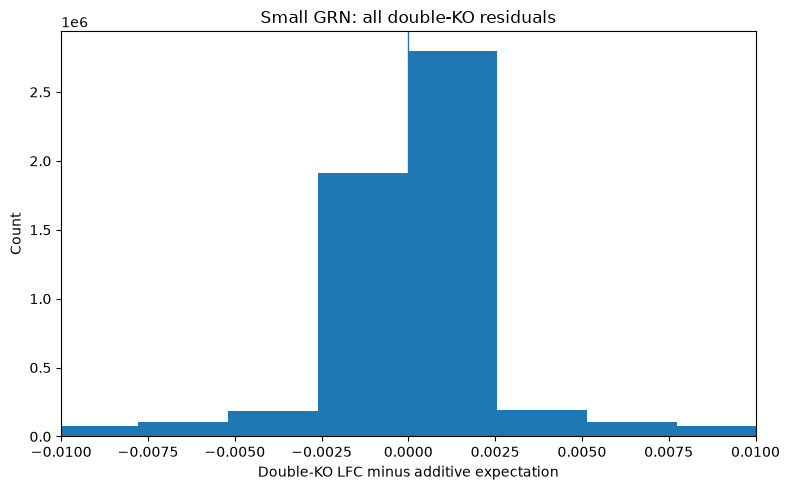

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    errors,
    bins=30000
)

plt.axvline(0, linewidth=1)

plt.xlim(-0.01, 0.01)

plt.xlabel("Double-KO LFC minus additive expectation")
plt.ylabel("Count")
plt.title("Small GRN: all double-KO residuals")

plt.tight_layout()
plt.show()

In [46]:
errors

array([ 3.15507734e+00,  8.41847742e+00, -4.99613518e+00, ...,
       -7.73698001e-02, -1.05518375e+00,  8.80071394e-05],
      shape=(8355840,))

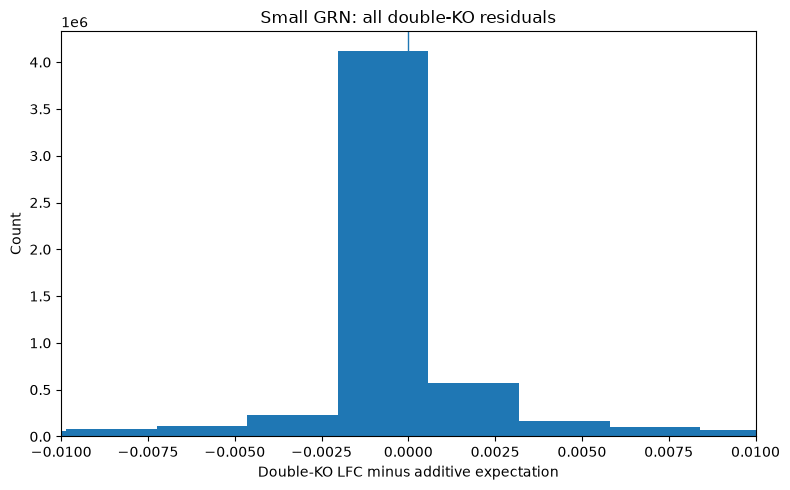

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    errors,
    bins=30000
)

plt.axvline(0, linewidth=1)

plt.xlim(-0.01, 0.01)

plt.xlabel("Double-KO LFC minus additive expectation")
plt.ylabel("Count")
plt.title("Small GRN: all double-KO residuals")

plt.tight_layout()
plt.show()

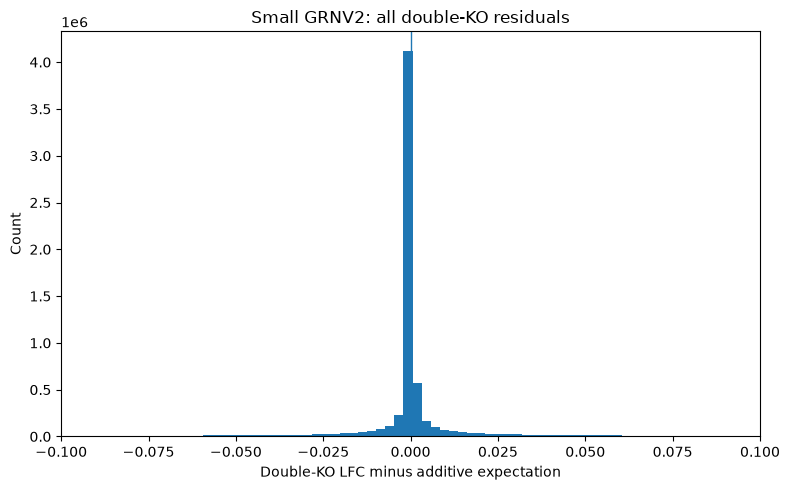

In [75]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    errors,
    bins=30000
)

plt.axvline(0, linewidth=1)

plt.xlim(-0.1, 0.1)

plt.xlabel("Double-KO LFC minus additive expectation")
plt.ylabel("Count")
plt.title("Small GRNV2: all double-KO residuals")

plt.tight_layout()
plt.show()

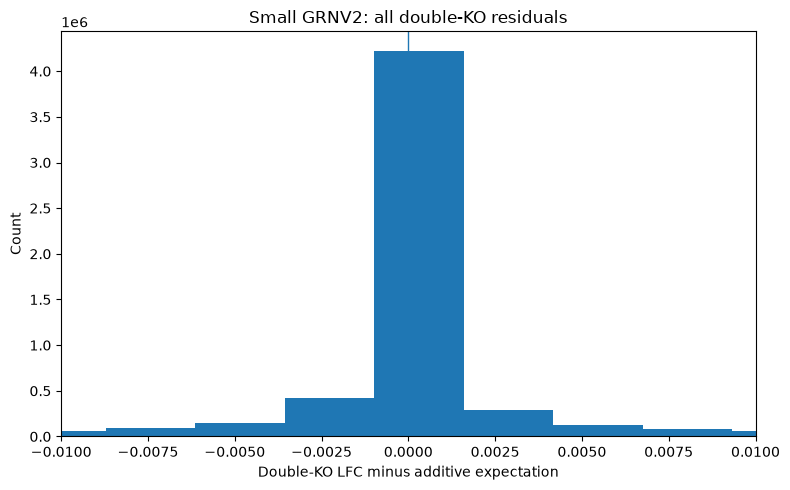

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    errors,
    bins=30000
)

plt.axvline(0, linewidth=1)

plt.xlim(-0.01, 0.01)

plt.xlabel("Double-KO LFC minus additive expectation")
plt.ylabel("Count")
plt.title("Small GRNV2: all double-KO residuals")

plt.tight_layout()
plt.show()

In [50]:
def run_double_ko(pair):
    a, b = pair

    result = G.ko_nodes(
        genes=[a, b],
        stats=("new_rna", "logfc"),
        s=1e-4,
        dt=1e-2,
        tmax=20000,
        burnin=5000,
        tol=1e-3,
    )

    return (
        np.asarray(result["new_rna"]).flatten(),
        np.asarray(result["logfc"]).flatten(),
    )


results = Parallel(
    n_jobs=4,
    pre_dispatch="n_jobs",
    prefer="processes",
    verbose=10,
)(
    delayed(run_double_ko)(pair)
    for pair in pairs
)

double_expression = np.asarray(
    [r[0] for r in results],
    dtype=np.float32
)

double_logfc = np.asarray(
    [r[1] for r in results],
    dtype=np.float32
)

print("double_expression:", double_expression.shape)
print("double_logfc:", double_logfc.shape)

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   1 tasks      | elapsed:    1.4s
[Parallel(n_jobs=4)]: Done   4 tasks      | elapsed:    1.5s
[Parallel(n_jobs=4)]: Done   9 tasks      | elapsed:    1.8s
[Parallel(n_jobs=4)]: Done  14 tasks      | elapsed:    2.1s
[Parallel(n_jobs=4)]: Done  21 tasks      | elapsed:    2.6s
[Parallel(n_jobs=4)]: Done  28 tasks      | elapsed:    3.0s
[Parallel(n_jobs=4)]: Done  37 tasks      | elapsed:    3.5s
[Parallel(n_jobs=4)]: Done  46 tasks      | elapsed:    4.0s
[Parallel(n_jobs=4)]: Done  57 tasks      | elapsed:    4.7s
[Parallel(n_jobs=4)]: Done  68 tasks      | elapsed:    5.5s
[Parallel(n_jobs=4)]: Done  81 tasks      | elapsed:    6.3s
[Parallel(n_jobs=4)]: Done  94 tasks      | elapsed:    7.1s
[Parallel(n_jobs=4)]: Done 109 tasks      | elapsed:    8.1s
[Parallel(n_jobs=4)]: Done 124 tasks      | elapsed:    8.9s
[Parallel(n_jobs=4)]: Done 141 tasks      | elapsed:   10.1s
[Parallel(

double_expression: (32640, 256)
double_logfc: (32640, 256)


[Parallel(n_jobs=4)]: Done 32640 out of 32640 | elapsed: 35.4min finished


In [76]:
double_expression

array([[8.79884943e-10, 1.10014129e+00, 1.69376028e-03, ...,
        9.58194062e-02, 1.22412592e-01, 4.53814834e-01],
       [5.00644026e-10, 4.23865885e-01, 3.89926904e-03, ...,
        6.04927130e-02, 1.23389497e-01, 4.53832090e-01],
       [6.78373580e-10, 4.19066429e-01, 3.77557683e-03, ...,
        6.08234219e-02, 1.22788675e-01, 4.53825682e-01],
       ...,
       [1.38208978e-09, 4.18968171e-01, 3.77080869e-03, ...,
        6.08280674e-02, 1.22792773e-01, 4.53817815e-01],
       [4.77811679e-10, 4.19018239e-01, 3.77329020e-03, ...,
        6.08150810e-02, 1.22797579e-01, 4.53815192e-01],
       [5.67378478e-10, 4.19009715e-01, 3.77438567e-03, ...,
        6.08159602e-02, 1.22794278e-01, 4.53809500e-01]],
      shape=(32640, 256), dtype=float32)

In [53]:
np.savez_compressed(
    "../256small_GRN_all_double_KO_exp.npz",
    pairs=pairs,
    double_expr=double_expression,
)

print("Saved 256small_GRN_all_double_KO_exp.npz")

Saved 256small_GRN_all_double_KO_exp.npz


In [2]:
with np.load("../256small_GRN_all_double_KO_exp.npz") as data:
    pairs = data["pairs"]
    double_expression = data["double_expr"]

In [7]:
double_expression 

array([[0.22902459, 0.26820517, 0.12691699, ..., 0.23021702, 0.07571758,
        0.03744688],
       [0.19038707, 0.17882472, 0.15229994, ..., 0.27422905, 0.06395153,
        0.02563071],
       [0.18919596, 0.24381807, 0.10982393, ..., 0.24741939, 0.07401819,
        0.03559477],
       ...,
       [0.18932737, 0.26252168, 0.0791078 , ..., 0.28473815, 0.07106488,
        0.03248731],
       [0.18931797, 0.26252457, 0.07910712, ..., 0.28471857, 0.07106034,
        0.03248477],
       [0.18929853, 0.26252174, 0.0791178 , ..., 0.2847334 , 0.07106682,
        0.03248161]], shape=(32640, 256), dtype=float32)

In [8]:
pairs

array([[  0,   1],
       [  0,   2],
       [  0,   3],
       ...,
       [253, 254],
       [253, 255],
       [254, 255]], shape=(32640, 2), dtype=int32)

In [10]:
G.rna.shape

(256,)

In [21]:
double_logfc = np.log2(double_expression) - np.log2(G.rna)

In [17]:
double_expression

array([[0.22902459, 0.26820517, 0.12691699, ..., 0.23021702, 0.07571758,
        0.03744688],
       [0.19038707, 0.17882472, 0.15229994, ..., 0.27422905, 0.06395153,
        0.02563071],
       [0.18919596, 0.24381807, 0.10982393, ..., 0.24741939, 0.07401819,
        0.03559477],
       ...,
       [0.18932737, 0.26252168, 0.0791078 , ..., 0.28473815, 0.07106488,
        0.03248731],
       [0.18931797, 0.26252457, 0.07910712, ..., 0.28471857, 0.07106034,
        0.03248477],
       [0.18929853, 0.26252174, 0.0791178 , ..., 0.2847334 , 0.07106682,
        0.03248161]], shape=(32640, 256), dtype=float32)

In [78]:
np.savez_compressed(
    "../../../grn_benchmark/new_data/double_KO_expression.npz",
    pairs=np.asarray(pairs, dtype=np.int64),
    double_expr=np.asarray(double_expression, dtype=np.float32),
)

np.save(
    "../../../grn_benchmark/new_data/single_KO_expression.npy",
    np.asarray(ko_expression, dtype=np.float32),
)

np.save(
    "../../../grn_benchmark/new_data/rna.npy",
    np.asarray(wt_expression, dtype=np.float32).reshape(-1),
)

In [65]:
! mkdir ../../../grn_benchmark/new_data

In [66]:
ls ../../../grn_benchmark/new_data

In [79]:

print(pd.read_csv("../../../grn_benchmark/new_results/test_metrics.csv").to_string(index=False))

p = np.load("../../../grn_benchmark/new_results/test_predictions.npz")
test_pairs = p["pairs"]
observed = p["observed"]
mlp_predictions = p["mlp"]
ridge_predictions = p["ridge"]
additive_predictions = p["additive"]

   model      mse     rmse  mean_l2  standardized_rmse  mse_improvement_over_additive_pct  non_target_gene_rmse  delta_from_wt_pearson  implied_residual_pearson  implied_residual_spearman  large_residual_rmse  fraction_pairs_lower_mse_than_additive  negative_prediction_fraction
      WT 0.032441 0.180114 2.056907           1.973425                        -244.552757              0.180068                    NaN                  0.441657                   0.178307             0.582421                                0.107414                      0.000000
Additive 0.009415 0.097033 0.619820           1.814124                           0.000000              0.096814               0.875339                       NaN                        NaN             0.842321                                0.000000                      0.026101
   Ridge 0.006934 0.083270 0.880718           1.788866                          26.354804              0.083110               0.886625                  0.514329   

In [80]:
import pandas as pd

# Display test_metrics as a formatted Jupyter HTML table
df_metrics = pd.read_csv("../../../grn_benchmark/new_results/test_metrics.csv")
df_metrics

,model,mse,rmse,mean_l2,standardized_rmse,mse_improvement_over_additive_pct,non_target_gene_rmse,delta_from_wt_pearson,implied_residual_pearson,implied_residual_spearman,large_residual_rmse,fraction_pairs_lower_mse_than_additive,negative_prediction_fraction
0,WT,0.032441,0.180114,2.056907,1.973425,-244.552757,0.180068,NaN,0.441657,0.178307,0.582421,0.107414,0.000000
1,Additive,0.009415,0.097033,0.619820,1.814124,0.000000,0.096814,0.875339,NaN,NaN,0.842321,0.000000,0.026101
2,Ridge,0.006934,0.083270,0.880718,1.788866,26.354804,0.083110,0.886625,0.514329,0.124967,0.615783,0.159804,0.128482
3,MLP,0.004476,0.066901,0.631678,1.769753,52.463972,0.066699,0.928622,0.725928,0.138041,0.463348,0.160968,0.110850


In [87]:
import json

with open("../../../grn_benchmark/new_results/test_results.json", "r") as f:
  data = json.load(f)
data["bootstrap"]["MLP"]["mse_improvement_pct_ci95"]


[50.96355320109436, 53.949317996468395]

# Lets train MLP on toy 256 gene GRN

In [54]:
n_genes = G.n
n_double = len(pairs)

# X_double[i] contains two 1s: the two genes knocked out
X_double = np.zeros((n_double, n_genes), dtype=np.float32)

rows = np.arange(n_double)
X_double[rows, pairs[:, 0]] = 1.0
X_double[rows, pairs[:, 1]] = 1.0

Y_double = np.asarray(double_expression, dtype=np.float32)

print(X_double.shape)
print(Y_double.shape)

print("Example pair:", pairs[0])
print("Non-zero entries:", np.where(X_double[0] == 1)[0])

(32640, 256)
(32640, 256)
Example pair: [0 1]
Non-zero entries: [0 1]


In [55]:
rng = np.random.default_rng(42)

indices = rng.permutation(n_double)

n_test = int(0.50 * n_double)
n_val  = int(0.10 * n_double)

test_idx = indices[:n_test]
val_idx = indices[n_test:n_test + n_val]
train_idx = indices[n_test + n_val:]

print(
    len(train_idx),
    len(val_idx),
    len(test_idx)
)

13056 3264 16320


In [56]:
X_wt = np.zeros((1, n_genes), dtype=np.float32)
Y_wt = wt_expression.reshape(1, -1).astype(np.float32)

In [57]:
X_single = np.eye(n_genes, dtype=np.float32)
Y_single = np.asarray(ko_expression, dtype=np.float32)

In [58]:
X_train = np.concatenate([
    X_wt,
    X_single,
    X_double[train_idx]
], axis=0)

Y_train = np.concatenate([
    Y_wt,
    Y_single,
    Y_double[train_idx]
], axis=0)

X_val = X_double[val_idx]
Y_val = Y_double[val_idx]

X_test = X_double[test_idx]
Y_test = Y_double[test_idx]

print("train:", X_train.shape, Y_train.shape)
print("val:  ", X_val.shape, Y_val.shape)
print("test: ", X_test.shape, Y_test.shape)

train: (13313, 256) (13313, 256)
val:   (3264, 256) (3264, 256)
test:  (16320, 256) (16320, 256)


In [59]:
y_mean = Y_train.mean(axis=0)
y_std = Y_train.std(axis=0)

# Avoid division by ~zero for nearly invariant genes
y_std = np.maximum(y_std, 1e-6)

Y_train_scaled = (Y_train - y_mean) / y_std
Y_val_scaled   = (Y_val   - y_mean) / y_std
Y_test_scaled  = (Y_test  - y_mean) / y_std

In [63]:
np.save("single_KO_expression.npy", np.asarray(ko_expression))

In [ ]:
linear_model = nn.Linear(256, 256)


In [9]:
import torch
import torch.nn as nn

class PerturbationMLP(nn.Module):
    def __init__(self, n_genes=256):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(n_genes, 512),
            nn.GELU(),

            nn.Linear(512, 512),
            nn.GELU(),

            nn.Linear(512, n_genes)
        )

    def forward(self, x):
        return self.net(x)